# Imports

In [1]:
# ----------------- Load packages ------------------- #
import os
import contextlib
import io
import numpy as np
import pandas as pd
import mne
from scipy.io import loadmat
import warnings
import matplotlib.pyplot as plt
import time
from pathlib import Path
from datetime import datetime
from scipy.stats import spearmanr
import statsmodels.formula.api as smf
import math

from somnopy import *
from somnopy.somno import get_sosp, get_sosp_for_folder
from somnopy.event_detection import SO_detection, SP_detection, detect_swa
from somnopy.metrics import pac,event_lock
from somnopy.utils import set_up_raw
from somnopy.polysomnography import PolySomnoGraphy
from somnopy.YasaFunctions import YasaFunctions
import yasa
from lspopt import spectrogram_lspopt
from IPython.display import Image, display



c:\Users\Beast\anaconda3\envs\somnopy\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# YASA: Spectrogram and Sleep Staging on EDF files

The following code cells are examples of using the YasaFunctions class within somnopy. This class provides functions for different types of specific requested analyses such as core body temperature spectrogam overlays and correlations in an easy to use, callable format. 

To start, load in your eeg and hypnogram data from edf and mat/txt files. You also need to define a stage mapping by which your staging codes can be converted to YASA codes. The numbers on the lefthand side of the following stage_mapping variable are the numbers you can edit to correspond to the righthand side YASA codes

In [54]:
#change edf and hypnogram paths you would like to analyze

edf_path = r"Y:\SNL\FEMS\CBT\ryan_cbt\all_data\FEMS_01_S1.edf"
hypnogram_path = r"Y:\SNL\FEMS\CBT\ryan_cbt\all_data\FEMS_01_S1.mat"



#MATLAB TO YASA STAGE CODES
#the strings on the lefthand side are what is present in the txt and mat files
#the numbers on the right correspond to yasa codes
#change the strings on the left to match what is in the mat and txt files
#if they are numbers, remove the quotes. If they are letters, keep the quotes. EX: "W" vs 1


stage_mapping = {
    0: 0, #W
    1: 1, #N1
    2: 2, #N2
    3: 3, #N3
    5: 4, #REM
    6: -1, #ART
    7: -2 #UNS
}


Now, lets instantiate our class with our stage mapping and load our data from the EEG and hypnogram paths. A bunch of variables are returned when loading data if you would like to inspect them, their descriptions are listed below. To view one of these variables, just create a new code cell, type the name of the variable, and click run

In [49]:
#input_data is the EEG data stored as a dict where keys are strings of channel names
#channels is list of channel names
#hypno is the yasa hypnogram object
#recording_start is the recording startime in datetime string format
#sampling_rate is the sampling rate
#hyp_window is the epoch length for each hypnogram
#raw is the raw data

analyzer = YasaFunctions(stage_mapping=stage_mapping)
input_data, channels, hypno, recording_start, sampling_rate, hyp_window, raw = analyzer.load_yasa_from_edf(edf_path, hypnogram_path)

Extracting EDF parameters from Y:\SNL\FEMS\CBT\ryan_cbt\all_data\FEMS_05_S1.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 16577499  =      0.000 ... 33154.998 secs...


04-Jun-26 16:00:35 | WARNING | Hypnogram is LONGER than data by 25.00 seconds. Cropping hypnogram to match data.size.


The following code plots histogram scoring data aligned to the spectrogram of a single specific electrode. You can specify which electrode you would like to use based on the channels listed below, as well as choose what frequency band you would like to visualize with fmin and fmax

In [6]:
channels

['EOG1', 'EOG2', 'F3', 'F4', 'C3', 'C4', 'O1', 'O2', 'CHIN2', 'Fp1', 'Fp2']

c:\Users\Beast\anaconda3\envs\somnopy\Lib\site-packages\yasa\plotting.py:324: RuntimeWarning: divide by zero encountered in log10
  Sxx = 10 * np.log10(Sxx)  # Convert uV^2 / Hz --> dB / Hz


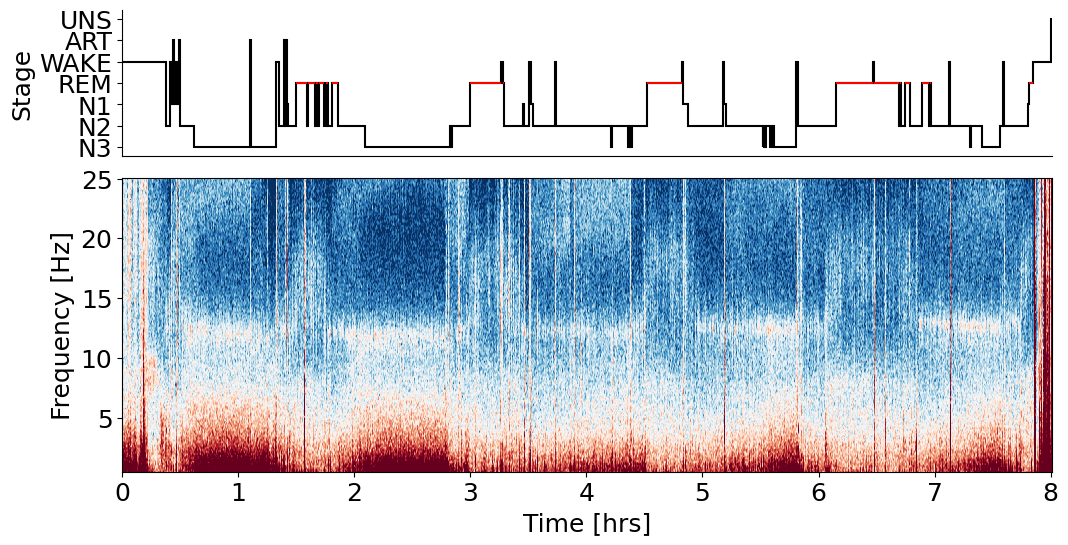

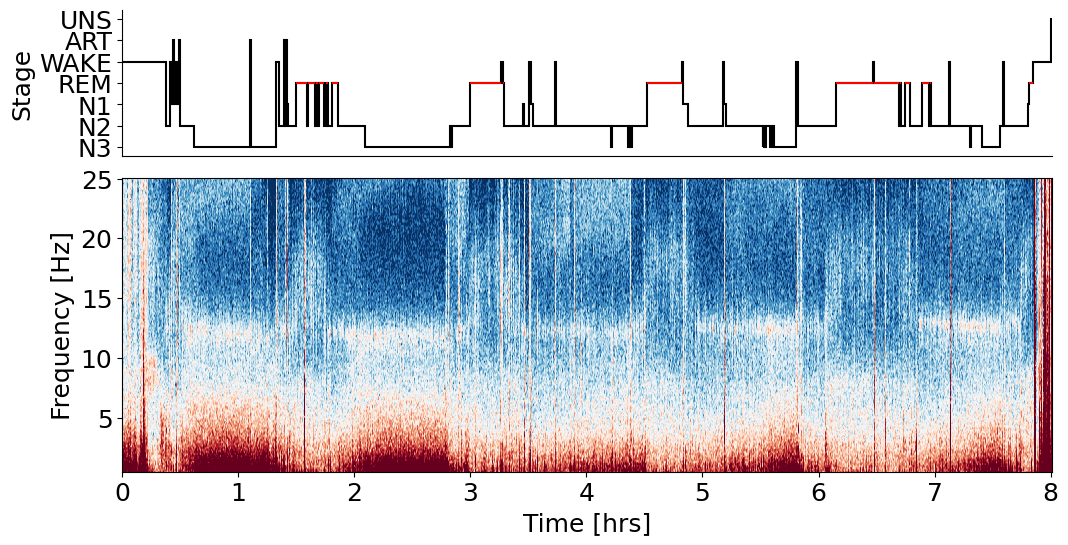

In [6]:
electrode = 'F4' #specify which electrode you want to examine
verbose = True #do you want to see the plot in the notebook or just save it to outpath? Set to True if you want to see it
outpath = None #specify the folder to save to 
filename = Path(edf_path).stem #what do you want to call your output file? 
fmin = 0.5 #OPTIONAL: what's the lowest frequency you would like to include in your spectrogram?
fmax=25 #OPTIONAL: what's the highest frequency you would like to include in your spectrogram?

analyzer.plot_single_electrode(electrode, verbose=verbose, outpath=outpath, filename=filename, fmin=fmin, fmax=fmax)

This next cell plots the same spectrogram / hypnogram combo above but for all electrodes within a recording

In [ ]:
verbose = True #do you want to see the plot in the notebook or just save it to outpath? Set to True if you want to see it
outpath = None #specify the folder to save to 
filename = Path(edf_path).stem #what do you want to call your output file? 
fmin = 0.5 #OPTIONAL: what's the lowest frequency you would like to include in your spectrogram?
fmax=4 #OPTIONAL: what's the highest frequency you would like to include in your spectrogram?

analyzer.plot_all_electrodes(verbose=verbose, outpath=outpath, filename=filename, fmin=fmin, fmax=fmax)

If you would like the spectrogram from an electrode in CSV format, run this next cell. CSV data is stored just like spectrogram data is, with rows corresponding to frequencies, columns corresponding to time, and values corresponding to power. 

In [ ]:
electrode = 'F3' #specify which electrode you want to examine
outpath = None #specify the folder to save to 
filename = Path(edf_path).stem #what do you want to call your output file? 
fmin = 0.5 #OPTIONAL: what's the lowest frequency you would like to include in your spectrogram?
fmax=4 #OPTIONAL: what's the highest frequency you would like to include in your spectrogram?

#uses the same spectrogram calculation methods as yasa
analyzer.save_spectrogram_csv(electrode, outpath=outpath, filename=filename, fmin=fmin, fmax=fmax)


The following code is for core body temperature analyis. First, lets load in our cbt data to our analyzer object. If you would like to load in new eeg and hypnogram data, just rerun the analyzer creation cell with your new eeg and hypnogram paths

In [7]:
cbt_path = r"Y:\SNL\FEMS\CBT\ryan_cbt\follicular_data\New\F4\FEMS_01_S1.xlsx" #filepath to the cbt data
cbt = analyzer.load_cbt(cbt_path)


This cell plots a single electrode spectrogram just as before, but now with a core body temperature reading overlay. 

c:\Users\Beast\anaconda3\envs\somnopy\Lib\site-packages\yasa\plotting.py:324: RuntimeWarning: divide by zero encountered in log10
  Sxx = 10 * np.log10(Sxx)  # Convert uV^2 / Hz --> dB / Hz


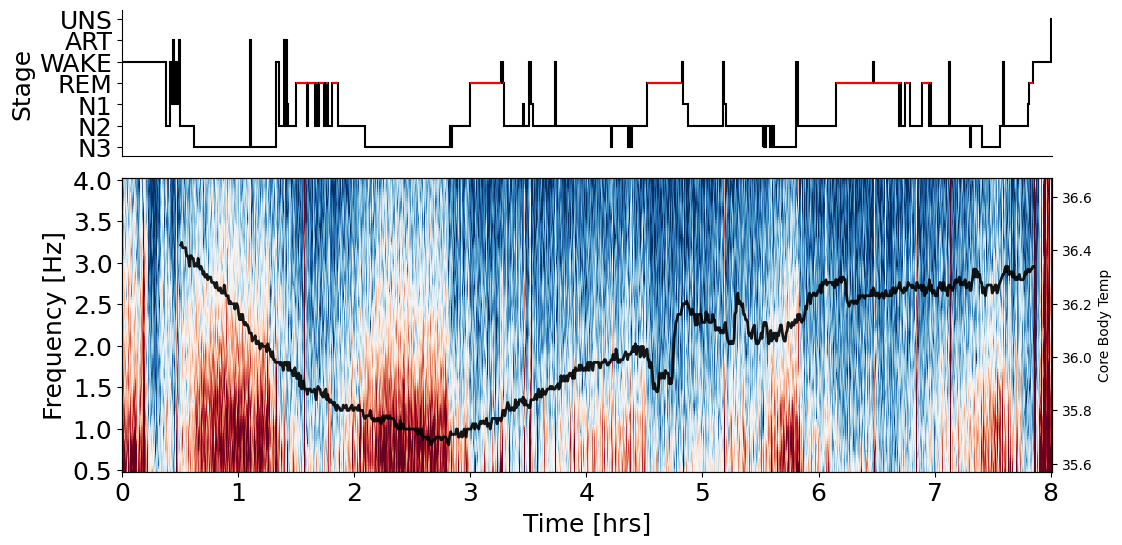

(<Figure size 1200x600 with 3 Axes>,
 <Axes: ylabel='Core Body Temp'>,
      Sample.number        date      hour   temp  decimal_time  Moving_Avg  \
 0             1737  11/05/2024  23:38:54  36.42     23.648333   36.444667   
 1             1738  11/05/2024  23:39:24  36.43     23.656667   36.439000   
 2             1739  11/05/2024  23:39:54  36.41     23.665000   36.433500   
 3             1740  11/05/2024  23:40:24  36.41     23.673333   36.427833   
 4             1741  11/05/2024  23:40:54  36.41     23.681667   36.422000   
 ..             ...         ...       ...    ...           ...         ...   
 878           2615  11/06/2024  06:57:55  36.32      6.965278         NaN   
 879           2616  11/06/2024  06:58:25  36.33      6.973611         NaN   
 880           2617  11/06/2024  06:58:55  36.33      6.981944         NaN   
 881           2618  11/06/2024  06:59:25  36.34      6.990278         NaN   
 882           2619  11/06/2024  06:59:55  36.34      6.998611         

In [8]:
electrode = 'F4' #specify which electrode you want to examine
verbose = True #do you want to see the plot in the notebook or just save it to outpath? Set to True if you want to see it
outpath = None #specify the folder to save to 
filename = Path(edf_path).stem #what do you want to call your output file? 
fmin = 0.5 #OPTIONAL: what's the lowest frequency you would like to include in your spectrogram?
fmax=4 #OPTIONAL: what's the highest frequency you would like to include in your spectrogram?



analyzer.plot_single_electrode_with_temp(electrode, verbose=verbose, outpath=outpath, filename=filename, fmin=fmin, fmax=fmax)

If you would like to batch process cbt / spectrogram overlays, specify your hypnogram, edf, and cbt folders. Matching file stems will be processed as one.

In [7]:
mat_folder = r"Y:\SNL\FEMS\CBT\ryan_cbt\follicular_data"
edf_folder = r"Y:\SNL\FEMS\CBT\ryan_cbt\follicular_data"
cbt_folder = r"Y:\SNL\FEMS\CBT\ryan_cbt\follicular_data"
out_folder = r"Y:\SNL\FEMS\CBT\ryan_cbt\follicular_spectrograms"
electrode="F3"
fmin=0.5
fmax=25


analyzer.batch_plot_spectrograms_with_temp(mat_folder, edf_folder, cbt_folder, out_folder, electrode=electrode, fmin=fmin, fmax=fmax)

Found 6 matched .mat/.edf/.xlsx filename sets.

Processing plot for: FEMS_01_S1
Extracting EDF parameters from Y:\SNL\FEMS\CBT\ryan_cbt\follicular_data\FEMS_01_S1.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 14442999  =      0.000 ... 28885.998 secs...


29-May-26 13:39:51 | WARNING | Hypnogram is LONGER than data by 4.00 seconds. Cropping hypnogram to match data.size.


✅ Saved plot for FEMS_01_S1

Processing plot for: FEMS_05_S1
Extracting EDF parameters from Y:\SNL\FEMS\CBT\ryan_cbt\follicular_data\FEMS_05_S1.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 16577499  =      0.000 ... 33154.998 secs...


29-May-26 13:40:23 | WARNING | Hypnogram is LONGER than data by 25.00 seconds. Cropping hypnogram to match data.size.


✅ Saved plot for FEMS_05_S1

Processing plot for: FEMS_10_S1
Extracting EDF parameters from Y:\SNL\FEMS\CBT\ryan_cbt\follicular_data\FEMS_10_S1.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 16490999  =      0.000 ... 32981.998 secs...


...

29-May-26 13:41:58 | WARNING | Hypnogram is LONGER than data by 3.00 seconds. Cropping hypnogram to match data.size.


✅ Saved plot for FEMS_16_S1

Processing plot for: FEMS_40_S2
Extracting EDF parameters from Y:\SNL\FEMS\CBT\ryan_cbt\follicular_data\FEMS_40_S2.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 15221999  =      0.000 ... 30443.998 secs...


29-May-26 13:42:28 | WARNING | Hypnogram is LONGER than data by 6.00 seconds. Cropping hypnogram to match data.size.


✅ Saved plot for FEMS_40_S2


,stem,edf_file,mat_file,xlsx_file,electrode,status,error
0,FEMS_01_S1,Y:\SNL\FEMS\CBT\ryan_cbt\follicular_data\FEMS_...,Y:\SNL\FEMS\CBT\ryan_cbt\follicular_data\FEMS_...,Y:\SNL\FEMS\CBT\ryan_cbt\follicular_data\FEMS_...,F3,success,None
1,FEMS_05_S1,Y:\SNL\FEMS\CBT\ryan_cbt\follicular_data\FEMS_...,Y:\SNL\FEMS\CBT\ryan_cbt\follicular_data\FEMS_...,Y:\SNL\FEMS\CBT\ryan_cbt\follicular_data\FEMS_...,F3,success,None
2,FEMS_10_S1,Y:\SNL\FEMS\CBT\ryan_cbt\follicular_data\FEMS_...,Y:\SNL\FEMS\CBT\ryan_cbt\follicular_data\FEMS_...,Y:\SNL\FEMS\CBT\ryan_cbt\follicular_data\FEMS_...,F3,success,None
3,FEMS_13_S1,Y:\SNL\FEMS\CBT\ryan_cbt\follicular_data\FEMS_...,Y:\SNL\FEMS\CBT\ryan_cbt\follicular_data\FEMS_...,Y:\SNL\FEMS\CBT\ryan_cbt\follicular_data\FEMS_...,F3,success,None
4,FEMS_16_S1,Y:\SNL\FEMS\CBT\ryan_cbt\follicular_data\FEMS_...,Y:\SNL\FEMS\CBT\ryan_cbt\follicular_data\FEMS_...,Y:\SNL\FEMS\CBT\ryan_cbt\follicular_data\FEMS_...,F3,success,None
5,FEMS_40_S2,Y:\SNL\FEMS\CBT\ryan_cbt\follicular_data\FEMS_...,Y:\SNL\FEMS\CBT\ryan_cbt\follicular_data\FEMS_...,Y:\SNL\FEMS\CBT\ryan_cbt\follicular_data\FEMS_...,F3,success,None


Here, instead of generating spectrograms we will perform a batch correlation analysis using spearmans r to correlate cbt with frequency bandpower at each timepoint

In [ ]:
mat_folder = r"Y:\SNL\FEMS\PSG\PSG Scoring"
edf_folder = r"Y:\SNL\FEMS\PSG\SOSP\processed_eeg_folder"
cbt_folder = r"Y:\SNL\FEMS\CBT\Analysis - Data\Cleaned_Files\Follicular and Luteal"
out_folder = r"c:\Users\Beast\Ryan\somnopy\somnopy\output\test"
electrode="F3"
fmin=0.5
fmax=4

analyzer.batch_correlate_cbt_with_bandpower(mat_folder, edf_folder, cbt_folder, out_folder, electrode, stage_mapping, band=(fmin, fmax), )

# Quadrant Analysis

Perform a comparison of stage percentages across the 4 quadrants of sleep across the follicular and lutea phases

In [ ]:
follicular_data = r"Y:\SNL\FEMS\CBT\ryan_cbt\follicular_data\New"
luteal_data = r"Y:\SNL\FEMS\CBT\ryan_cbt\luteal_data\New"
sleep_window_path = r"Y:\SNL\FEMS\CBT\ryan_cbt\sleep_start_stop.xlsx"
result_dir = None

hours_per_stage_per_quadrant = analyzer.plot_stage_hours_by_quadrant(
    follicular_folder=follicular_data,
    luteal_folder=luteal_data,
    sleep_window_path=sleep_window_path,
    save_dir=result_dir
)

# Core Body Temperature Slope From Sleep Onset to N3 Start vs Time to N3 Start Regression

In [ ]:
mat_folder = r"Y:\SNL\FEMS\CBT\ryan_cbt\all_data"
edf_folder = r"Y:\SNL\FEMS\CBT\ryan_cbt\all_data"
cbt_folder = r"Y:\SNL\FEMS\CBT\ryan_cbt\all_data"

stage_names = {"N2": 2, "N3": 3, "REM": 4}
for stage_name, stage_code in stage_names.items():
    out_folder = None

    results_df, cbt_slope_data, group_regression_df = analyzer.cbt_slope_sleep_onset_to_stage(
        mat_folder=mat_folder,
        edf_folder=edf_folder,
        cbt_folder=cbt_folder,
        out_folder=out_folder,
        stage_name=stage_name,
        stage_names=stage_names
    )